# Lab6 (Students version): robustness of a graph 

We can use the following libraries.

In [1]:
import matplotlib.pyplot as plt
import math
import sys
from random import *
from collections import deque
print(sys.version)

3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]


In this lab session, we investigate the notion of robustness of a graph: how well a graph remains connected when nodes disappear following random failures or degree-based failures.

## Exercise 1: preliminary work

### Question 1

Using the code seen in previous labs, load the graph "IP_inet-undir.txt" available on Moodle as a dictionary of lists:

In [2]:
from collections import defaultdict
import os

def load_undirected_edge_list(path):
    g = defaultdict(set)
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            u, v = map(int, line.split())
            g[u].add(v)
            g[v].add(u)
    return dict(g)  # dict[node] -> set(neighbors)



inet = load_undirected_edge_list("IP-inet-undir.txt")
print("#nodes", len(inet), "#edges", sum(len(v) for v in inet.values()) // 2)


#nodes 9740 #edges 35567


### Question 2

Determine the size of the largest connected component (LCC) of a graph, and use the code to determine the size of the LCC of the example graph.

Suggested implementation:

- Create a function that takes a graph as input and outputs a dictionary of the connected component that each node belongs to. (This function is derived from a BFS).

- Then, create another function which takes the dictionary of the connected components as input and computes the size of the largest connected component of the graph.

In [4]:
def node_to_component(g):
    """Return dict: node -> component id, using BFS."""
    comp = {}
    cid = 0

    for start in g:
        if start in comp:
            continue
        cid += 1
        q = deque([start])
        comp[start] = cid
        while q:
            u = q.popleft()
            for v in g[u]:
                if v in g and v not in comp:
                    comp[v] = cid
                    q.append(v)
    return comp

def lcc_size(g):
    comp = node_to_component(g)
    if not comp:
        return 0
    counts = {}
    for c in comp.values():
        counts[c] = counts.get(c, 0) + 1
    return max(counts.values())

print("LCC size:", lcc_size(inet))


LCC size: 8557


## Exercise 2: robustness to random failures

### Question 3

In this question, we plot the size of the LCC as a function of the number of nodes removed. 

Nodes are removed randomly. It is a way to evaluate the robustness of the network to random failures.

Suggested implementation:

- create a function that deletes either $n_s$ nodes all at once or one by one

- use the function of Question 2 to compute the size of the LCC at each step and save it

- combine these two functions to get a dictionary which keys are the number of nodes currently removed and values are the corresponding size of the LCC




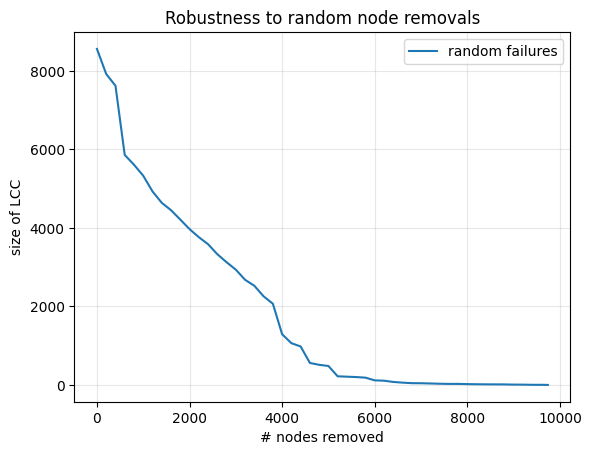

In [10]:
import random

def copy_graph(g):
    return {u: set(nei) for u, nei in g.items()}

def remove_node_inplace(g, u):
    if u not in g:
        return
    for v in list(g[u]):
        if v in g:
            g[v].discard(u)
    del g[u]

def robustness_curve(g, removal_order, step=200):
    gg = copy_graph(g)
    x = [0]
    y = [lcc_size(gg)]
    for i, u in enumerate(removal_order, start=1):
        remove_node_inplace(gg, u)
        if i % step == 0 or i == len(removal_order):
            x.append(i)
            y.append(lcc_size(gg))
    return x, y

nodes = list(inet.keys())
random.shuffle(nodes)

x_r, y_r = robustness_curve(inet, nodes, step=200)

plt.figure()
plt.plot(x_r, y_r, label="random failures")
plt.xlabel("# nodes removed")
plt.ylabel("size of LCC")
plt.title("Robustness to random node removals")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Exercise 3: robustness to targeted (degree-based) failures 

### Question 4

In this question, we do the same as in the previous question, except for the fact that nodes are not chosen randomly, but by decreasing degree order.

Suggested implementation:

- create a function that outputs a list of nodes ordered by decreasing degree

- then follow the same principle as in the previous question

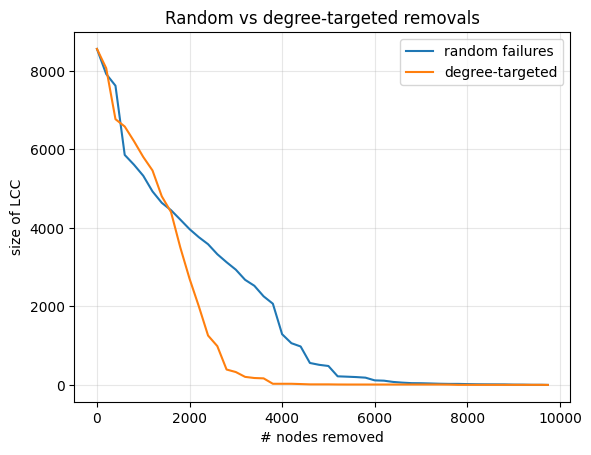

In [11]:
# Nodes removed in decreasing order of (initial) degree
order_deg = sorted(inet.keys(), key=lambda u: len(inet[u]), reverse=True)

x_d, y_d = robustness_curve(inet, order_deg, step=200)

plt.figure()
plt.plot(x_r, y_r, label="random failures")
plt.plot(x_d, y_d, label="degree-targeted")
plt.xlabel("# nodes removed")
plt.ylabel("size of LCC")
plt.title("Random vs degree-targeted removals")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Question 5

Compare the two curves (random deletions and targeted deletions): are they different? What does it mean?

    If the degree-targeted curve drops much faster than the random-failure curve, 
    the network is robust to random failures but fragile to targeted attacks. 
    This typically indicates the presence of hubs (heterogeneous degree distribution)


### Question 6

Do the same thing but now with targeted (closeness and betweenness based) failures


In [12]:
# indications : BC and CC will be computed with NetworkX 
import networkx as nx
inet_nx = nx.Graph(inet)
dico_closeness = nx.closeness_centrality(inet_nx)
dico_betweenness = nx.betweenness_centrality(inet_nx)


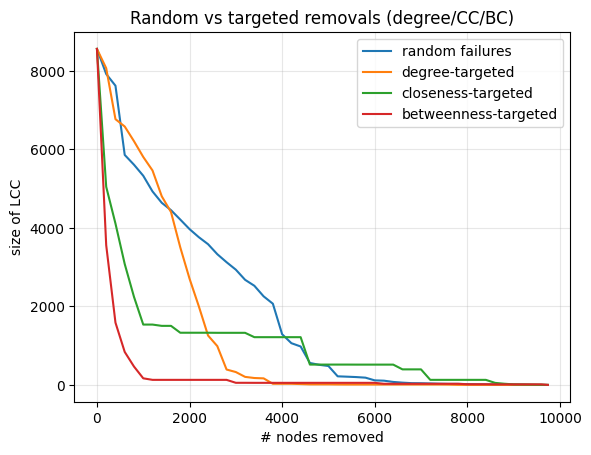

In [14]:
# Targeted removals by centrality (computed above with NetworkX)
order_c = sorted(dico_closeness, key=dico_closeness.get, reverse=True)
order_b = sorted(dico_betweenness, key=dico_betweenness.get, reverse=True)

x_c, y_c = robustness_curve(inet, order_c, step=200)
x_b, y_b = robustness_curve(inet, order_b, step=200)

plt.figure()
plt.plot(x_r, y_r, label="random failures")
plt.plot(x_d, y_d, label="degree-targeted")
plt.plot(x_c, y_c, label="closeness-targeted")
plt.plot(x_b, y_b, label="betweenness-targeted")
plt.xlabel("# nodes removed")
plt.ylabel("size of LCC")
plt.title("Random vs targeted removals (degree/CC/BC)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Question 7

Which measure is the fastest one to disconnect the network? What do you think about it ? 


The fastest is the curve that reaches the smallest LCC with the fewest removals, this is oftena betweeness targeted discconect due to it targetting the network itself such as bridge and connector nodes